 **Name:** Zainab Sarfraz

 **Task Title:** Industrial Training Kit

 **Assigned Task:** Data Science

**Import libraries:** The following libraries are imported to perform specific functions on the dataset of data analytics.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()
print("All the libraries are imported.")

Saving Dataset for Data Analytics - Sheet1.csv to Dataset for Data Analytics - Sheet1 (1).csv
All the libraries are imported.


In [8]:
df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")

**Basic Expolatory Data Analysis (EDA):** The basic EDA are head,shape,info,describe,columns to analyze or understand the working of data.

In [10]:
df.head(10)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,NaN,Email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52


In [11]:
df.shape

(1200, 14)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [14]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [15]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

**Missing Value Analysis:** This is used to check the missing value in the columns or in the dataset. So, the values are filled with some values to make the report more better and organized.

In [16]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [20]:
df['CouponCode'] = df['CouponCode'].fillna(df['CouponCode'].mode()[0])

In [51]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


**Outliers Detection:** The outliers are used to detect the missing values, repeated values or wrong values from misleading the data.

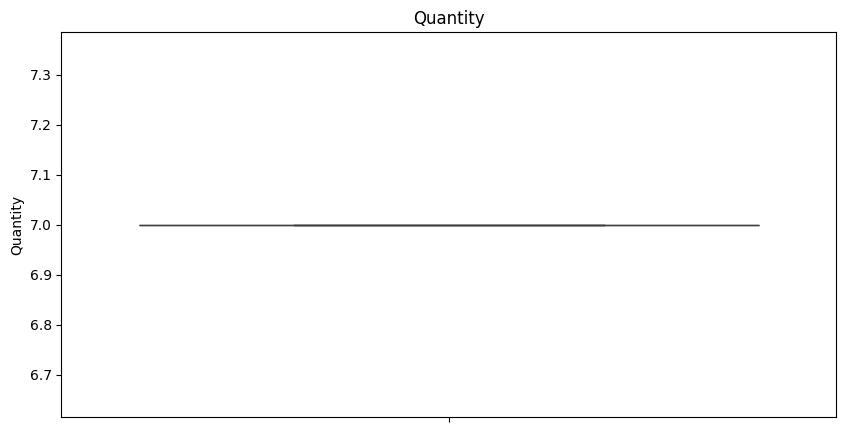

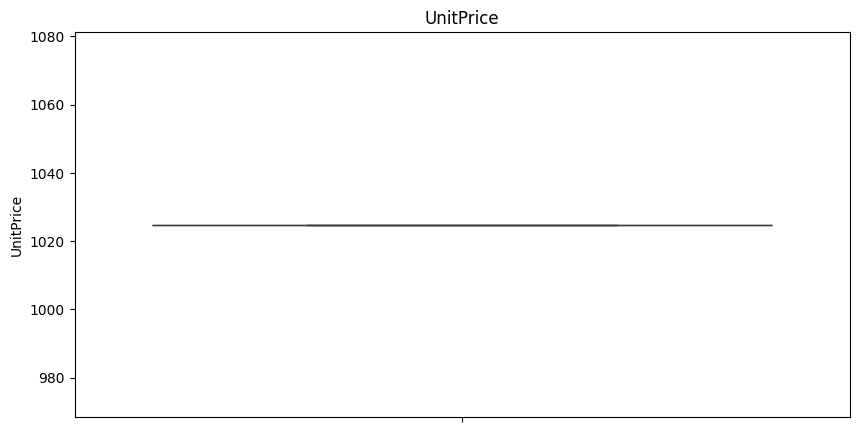

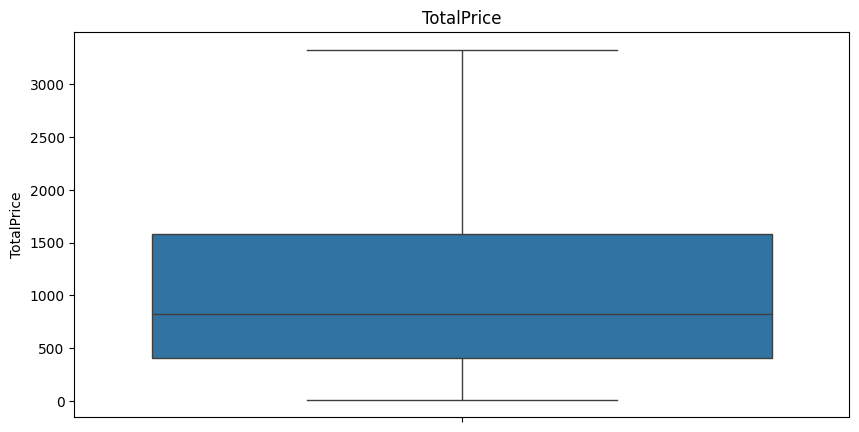

In [47]:
numeric_columns = ['Quantity', 'UnitPrice', 'TotalPrice']
for col in numeric_columns:
  plt.figure(figsize=(10, 5))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

**Outliers Treatment:** These are used to remove the wrong values from the data and to find the exact interquartile range for data being in the limit.

In [48]:
for col in numeric_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  interquartile_range = Q3 - Q1
  lower_range = Q1 - 1.5 * range
  upper_range = Q3 + 1.5 * range
  df[col] = df[col].clip(lower_range, upper_range)

In [27]:
print(numeric_columns)

['Quantity', 'UnitPrice', 'PaymentMethod', 'TotalPrice']


**Feature engineering:** This is used to make new columns to test the model for its performance.

In [33]:
df['HasCoupon'] = df['CouponCode'].apply(
    lambda x: 1 if pd.notnull(x) else 0
)

In [35]:
df['Date'] = pd.to_datetime(df['Date']).dt.month

In [52]:
df['Order_day_of_the_week'] = pd.to_datetime(df['Date']).dt.day_name()

**Visualizations:** To visualize the plots of the data and correlation function is also used to find the relations between the columns y using colors.

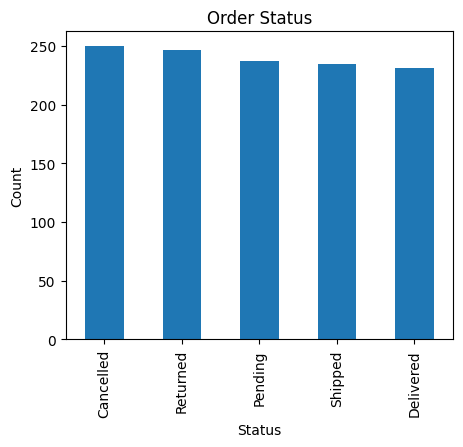

In [38]:
plt.figure(figsize = (5,4))
df['OrderStatus'].value_counts().plot(kind = 'bar')
plt.title('Order Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

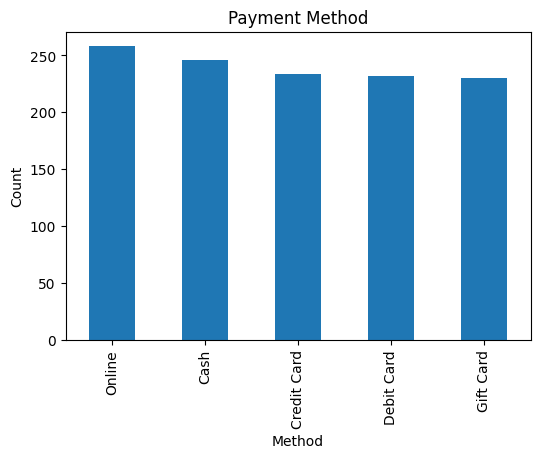

In [39]:
plt.figure(figsize = (6,4))
df['PaymentMethod'].value_counts().plot(kind = 'bar')
plt.title('Payment Method')
plt.xlabel('Method')
plt.ylabel('Count')
plt.show()

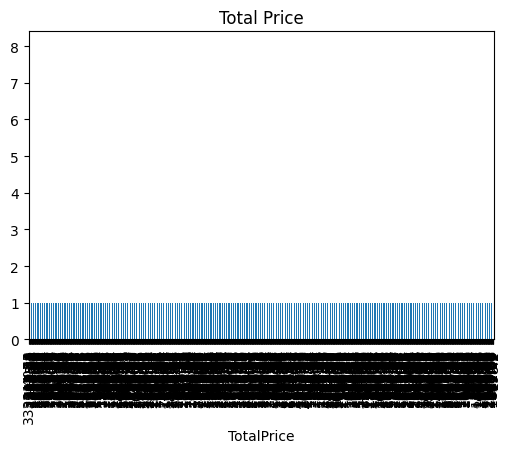

In [41]:
plt.figure(figsize = (6,4))
df['TotalPrice'].value_counts().plot(kind = 'bar')
plt.title('Total Price')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


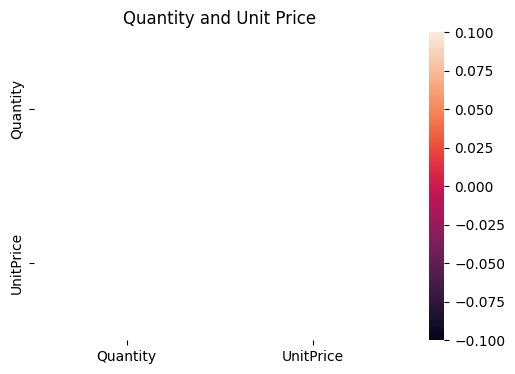

In [50]:
plt.figure(figsize = (6,4))
sns.heatmap(df[['Quantity', 'UnitPrice']].corr(), annot = True)
plt.title('Quantity and Unit Price')
plt.show()

**Conclusions:** It is just used to convert the dataframe into csv file and then save it. The index is used to ignore the unsual things in the data that effects the beauty of the data.

In [46]:
df.to_csv('cleaned_data.csv', index = False)